Exerice 1
Why Visualization: Visualizations reveal patterns, trends, outliers, and relationships that are hard to see in raw numbers; they aid communication and faster decision-making.
Line Graph Purpose: A line graph shows how a numeric variable changes over an ordered dimension (usually time), making trends and cycles easy to spot.

In [ ]:
#Exerice 2
import matplotlib.pyplot as plt

temps = [72, 74, 76, 80, 82, 78, 75]
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(8,4))
plt.plot(days, temps, marker='o', color='tab:blue')
plt.xlabel('Day')
plt.ylabel('Temperature (°F)')
plt.title('Temperature Variation Over a Week')
plt.grid(True)
plt.show()

In [ ]:
#Exerice 3
import matplotlib.pyplot as plt

sales = [5000, 5500, 6200, 7000, 7500]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May']

plt.figure(figsize=(8,4))
plt.bar(months, sales, color='skyblue')
plt.xlabel('Month')
plt.ylabel('Sales Amount ($)')
plt.title('Monthly Sales')
plt.show()

In [2]:
#Exerice 4
import requests, io, zipfile, pandas as pd

url = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%203/W3D1%20-%20Data%20Visualization/Student%20Mental%20health.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
csv_files = [n for n in z.namelist() if n.lower().endswith('.csv')]
df = pd.read_csv(z.open(csv_files[0]))
print(df.head())

        Timestamp Choose your gender   Age What is your course?  \
0  8/7/2020 12:02             Female  18.0          Engineering   
1  8/7/2020 12:04               Male  21.0    Islamic education   
2  8/7/2020 12:05               Male  19.0                  BIT   
3  8/7/2020 12:06             Female  22.0                 Laws   
4  8/7/2020 12:13               Male  23.0         Mathemathics   

  Your current year of Study What is your CGPA? Marital status  \
0                     year 1        3.00 - 3.49             No   
1                     year 2        3.00 - 3.49             No   
2                     Year 1        3.00 - 3.49             No   
3                     year 3        3.00 - 3.49            Yes   
4                     year 4        3.00 - 3.49             No   

  Do you have Depression? Do you have Anxiety? Do you have Panic attack?  \
0                     Yes                   No                       Yes   
1                      No                  Yes  

C:\Users\DELL\AppData\Local\Temp\ipykernel_9108\3015515266.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yes_prop, x='Choose your gender', y='proportion', palette='pastel')


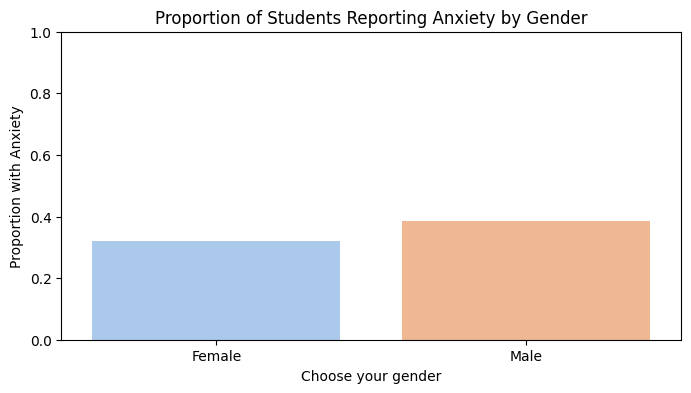

In [4]:
#Exerice 5
import seaborn as sns
import matplotlib.pyplot as plt

# group counts and compute proportion of "Yes" per gender
counts = df.groupby(['Choose your gender','Do you have Anxiety?']).size().reset_index(name='count')
counts['total_by_gender'] = counts.groupby('Choose your gender')['count'].transform('sum')
counts['proportion'] = counts['count'] / counts['total_by_gender']

yes_prop = counts[counts['Do you have Anxiety?'].str.lower().isin(['yes','y', 'true']) | (counts['Do you have Anxiety?']=='Yes')]
plt.figure(figsize=(8,4))
sns.barplot(data=yes_prop, x='Choose your gender', y='proportion', palette='pastel')
plt.ylabel('Proportion with Anxiety')
plt.title('Proportion of Students Reporting Anxiety by Gender')
plt.ylim(0,1)
plt.show()

In [5]:
#Exerice 6
import seaborn as sns
import matplotlib.pyplot as plt

# map panic answers to numeric
df['panic_numeric'] = df['Do you have Panic Attacks?'].map(lambda v: 1 if str(v).strip().lower() in ('yes','y','true') else 0)

plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='Age', y='panic_numeric', hue='panic_numeric', palette='coolwarm', alpha=0.6, s=60)
plt.yticks([0,1], ['No','Yes'])
plt.xlabel('Age')
plt.ylabel('Panic Attacks (No=0, Yes=1)')
plt.title('Age vs. Panic Attack Occurrence')
plt.legend([],[], frameon=False)
plt.show()

KeyError: 'Do you have Panic Attacks?'